In [1]:
import numpy as np
import json
from neuromancer.system import Node, System
from neuromancer.dynamics import ode, integrators

from SparseDPC.vectorized.utils import DoubleIntegrator2D, CustomLogger, solve_and_plot_ipopt
from SparseDPC.vectorized.sindy import CompiledFunctionLibrary, SINDyVectorized
from SparseDPC.vectorized.trainer import SparseTrainer, SparsePolicyBuilder
from SparseDPC.vectorized.data import get_policy_data
from SparseDPC.vectorized.plot import *

import neuromancer.psl as psl
from utils import *

# Use GPU if available, otherwise fallback to CPU
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")


In [2]:
import numpy as np
from neuromancer.psl.signals import step
from neuromancer.psl.base import ODE_NonAutonomous as ODE
from neuromancer.psl.base import cast_backend

class VanDerPolControl(ODE):
    """
    Van der Pol oscillator modified to have relative degree 1 for y = x0.

    Dynamics:
        dx0/dt = x1 + u0
        dx1/dt = mu * (1 - x0^2) * x1 - x0 + u1

    Inputs:
        u0 acts directly on dx0 (gives relative degree 1 w.r.t. y = x0)
        u1 acts on dx1 (original channel)
    Notes:
        - Two input channels are provided in U with shape (nsim, 2): [u0, u1].
        - get_U() returns independent step signals for u0 and u1 by default.
    """

    @property
    def params(self):
        """
        Initializes:
            x0: initial state (2,)
            U: placeholder array with two columns for [u0, u1]
            ts: sampling time
            mu: Van der Pol parameter
        """
        variables = {
            'x0': self.rng.standard_normal(2),
            'U': 0.5 * np.cos(np.arange(0., self.nsim+1) * 0.02).reshape(-1, 1).repeat(2, axis=1)
        }
        constants = {'ts': 0.1}
        parameters = {'mu': 1.0}
        meta = {}
        return variables, constants, parameters, meta

    @cast_backend
    def equations(self, t, x, u):
        """
        Right-hand side of the ODE with two inputs u = [u0, u1].
        """
        dx0 = x[1] + u[0]
        dx1 = self.mu * (1 - x[0]**2) * x[1] - x[0] + u[1]
        return [dx0, dx1]

    @cast_backend
    def get_U(self, nsim, signal=None, **signal_kwargs):
        """
        Default input generator:
            Returns two independent piecewise-constant step signals for [u0, u1].
        """
        if signal is not None:
            return super().get_U(nsim=nsim, signal=signal, **signal_kwargs)
        u0 = step(nsim=nsim, d=1, min=-0.5, max=0.5,
                  randsteps=int(np.ceil(nsim / 200)), rng=self.rng)
        u1 = step(nsim=nsim, d=1, min=-0.5, max=0.5,
                  randsteps=int(np.ceil(nsim / 200)), rng=self.rng)
        return np.concatenate([u0, u1], axis=1)

# ground truth system model
gt_model = VanDerPolControl()
# sampling rate
ts = gt_model.params[1]['ts']
# problem dimensions
nx = gt_model.nx    # number of states
nu = gt_model.nu    # number of control inputs
nref = nx           # number of references
# constraints bounds
umin = -1
umax = 1
xmin = -5.
xmax = 5.



## Load Dynamics and Policy Models

Restore the required checkpoints.


In [3]:
import torch
import torch.nn as nn

import torch

run_id = 1
models_dir = f"../results/models/dynamics/run_{run_id}/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/sindy.pt", map_location=device)

# Rebuild library and model skeleton
lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
sindy = SINDyVectorized(
    library=lib,
    n_out=ckpt["model_cfg"]["n_out"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
sindy.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(sindy.active_idx):
    sindy.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
sindy._plan = sindy._recompile_fast_path(device=device)

# Load weights
sindy.load_state_dict(ckpt["state_dict"], strict=True)


/var/folders/7d/4w2xzdbj279fj424x2h2w2xh0000gn/T/ipykernel_46677/41613913.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(str(models_dir) + "/sindy.pt"

<All keys matched successfully>

In [ ]:
import torch
import torch.nn as nn


import torch

run_id = 1
models_dir = f"../results/models/policies/sd_dpc/run_{run_id}/saved_models"   # change root here
ckpt = torch.load(str(models_dir) + "/policy_sparse.pt", map_location=device)

# Rebuild library and model skeleton
policy_lib = CompiledFunctionLibrary(**ckpt["lib_cfg"])
policy_sparse = SINDyVectorized(
    library=policy_lib,
    n_out=ckpt["model_cfg"]["n_out"],
    policy_name=ckpt["model_cfg"]["policy_name"],
    device=device,
)

# Install pruning structure BEFORE loading weights (so shapes match)
policy_sparse.active_idx = [list(map(int, s)) for s in ckpt["active_idx"]]

# Resize Xi ParameterList to match saved shapes
for i, idxs in enumerate(policy_sparse.active_idx):
    policy_sparse.Xi[i] = nn.Parameter(torch.zeros(len(idxs), 1, device=device), requires_grad=True)

# Recompile the fast plan for the current union of terms
policy_sparse._plan = policy_sparse._recompile_fast_path(device=device)

# Load weights
policy_sparse.load_state_dict(ckpt["state_dict"], strict=True)


In [ ]:
### NEURAL NETWORK (NN) MODELS ###
from neuromancer.modules import blocks
from neuromancer.modules.activations import activations

nn_files = sorted(
    Path("../results/models/policies/nn_dpc").glob("run_*/saved_models"),
    key=lambda p: int(p.parent.name.split("_")[-1]),
)[-1]

net_policy = blocks.MLP_bounds(insize=nx + nref, outsize=nu, hsizes=[32,32],
                    nonlin=activations['gelu'], min=umin, max=umax)
nn_policy = Node(net_policy, ['xn', 'r'], ['u'], name='neural policy')
nn_policy.load_state_dict(torch.load(nn_files+"/policy_nn.pth", weights_only=True))

In [6]:
policy_sparse.pretty_print()

u0 = -2.2033e+00·x0 + +9.3273e-01·x1
u1 = -2.6315e+00·x1


In [7]:
sindy.pretty_print()

dx0/dt = +1.0000e+00·x1 + +9.9999e-01·u0
dx1/dt = -9.9999e-01·x0 + +9.9994e-01·x1 + +9.9999e-01·u1 + -1.0000e+00·x0^2*x1


### 📊 Get data

Gets training, dev, and test datasets using the ground truth model.


In [8]:
from SparseDPC.data.getdata import get_data

torch.manual_seed(0)


nsim = 1500   # number of simulation steps in the dataset
nsteps = 2  # number of prediction horizon steps in the loss function
bs = 1500     # minibatching batch size
train_loader, dev_loader, test_data = get_data(gt_model, nsim, nsteps, ts, bs)

### Dynamics rollout

Inspect the learned dynamics.


In [9]:
# Full-state integration using all fx_models
integrator_x = integrators.RK4(sindy, h=ts)
integrator_node_x = Node(integrator_x, ['xn', 'u'], [f'xn'], name="x_integrator")
dynamics_model_x = System([integrator_node_x])
dynamics_model_x.nsteps = test_data['X'].shape[1]


# Run simulation
test_output = dynamics_model_x(test_data)
pred_traj = test_output['xn'][:, :-1, :].detach().numpy().reshape(-1, nx).T
true_traj = test_data['X'].detach().numpy().reshape(-1, nx).T


In [10]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.ticker import MaxNLocator, MultipleLocator
from pathlib import Path
from typing import Callable, Optional, Union


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _apply_automatica_style():
    """
    Publication-style settings inspired by IFAC Automatica conventions.
    """
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
        "font.size": 9,
        "axes.labelsize": 12,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "grid.linewidth": 0.4,
        "grid.alpha": 0.35,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 2.0,
        "ytick.minor.size": 2.0,
        "savefig.bbox": "tight",
        "figure.dpi": 300,
    })


def _draw_coefficient_heatmap(
    ax,
    data,
    xlabels,
    ylabels,
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    annot=True,
    annot_fmt=".2f",
    annot_fontsize=6.5,
    xrotation=90,
    border_linewidth=0.8,
):
    """
    Draw a compact academic heatmap using only matplotlib.
    data shape must be (n_rows, n_cols).
    """
    n_rows, n_cols = data.shape

    if vmin is None:
        vmin = np.min(data)
    if vmax is None:
        vmax = np.max(data)

    lim = max(abs(vmin), abs(vmax))
    vmin, vmax = -lim, lim

    im = ax.imshow(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
        interpolation="none",
        origin="upper",
    )

    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))
    ax.set_xticklabels(xlabels)
    ax.set_yticklabels(ylabels)

    ax.tick_params(axis="x", rotation=xrotation, pad=1)
    ax.tick_params(axis="y", rotation=0, pad=3)

    ax.xaxis.tick_bottom()

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)
    ax.grid(which="minor", color="black", linestyle="-", linewidth=0.4)
    ax.tick_params(which="minor", bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    rect = patches.Rectangle(
        (-0.5, -0.5),
        n_cols,
        n_rows,
        linewidth=border_linewidth,
        edgecolor="black",
        facecolor="none",
        clip_on=False,
        zorder=10,
    )
    ax.add_patch(rect)

    if annot:
        for i in range(n_rows):
            for j in range(n_cols):
                value = data[i, j]
                text_color = "white" if abs(value) > 0.55 * lim and lim > 0 else "black"
                ax.text(
                    j,
                    i,
                    format(value, annot_fmt),
                    ha="center",
                    va="center",
                    fontsize=annot_fontsize,
                    color=text_color,
                )

    return im


def plot_sindy_dynamics_automatica(
    test_output: dict,
    test_data: dict,
    sindy,
    nx: int,
    convert_to_latex: Callable,
    output_path: Union[str, Path] = "SINDy_Automatica.pdf",
    pred_key: str = "xn",
    true_key: str = "X",
    max_time_series_states: Optional[int] = None,
    figure_mode: str = "single",
    fig_width_single: float = 3,
    fig_width_double: float = 7,
    time_row_height: float = 1.05,
    heatmap_cell_width_in: float = 0.22,
    heatmap_cell_height_in: float = 0.28,
    legend_height_in: float = 0.28,
    top_margin_in: float = 0.18,
    bottom_margin_in: float = 0.18,
    side_margin_in: float = 0.24,
    gap_after_legend_in: float = 0.08,
    gap_between_ts_in: float = 0.08,
    gap_before_heatmap_in: float = 0.4,
    heatmap_max_width_ratio: float = 0.92,
    true_label: str = "Full simulation",
    pred_label: str = "SINDy",
    true_color: str = "black",
    pred_color: str = "tab:blue",
    pred_linestyle: str = "--",
    linewidth: float = 1.5,
    y_major_locator: Optional[float] = None,
    heatmap_cmap: str = "RdBu_r",
    show: bool = True,
    save: bool = True,
):
    """
    IFAC Automatica-style figure:
      1. stacked time-series subplots
      2. coefficient heatmap split into two stacked groups

    The heatmap terms are divided into two equal-size groups.
    """

    _apply_automatica_style()

    if pred_key not in test_output:
        raise KeyError(f"test_output does not contain key '{pred_key}'")

    if true_key not in test_data:
        raise KeyError(f"test_data does not contain key '{true_key}'")

    pred_raw = _to_numpy(test_output[pred_key])
    true_raw = _to_numpy(test_data[true_key])

    pred_traj = pred_raw[:, :-1, :].reshape(-1, nx).T
    true_traj = true_raw.reshape(-1, nx).T

    T_pred = pred_traj.shape[1]
    true_traj = true_traj[:, :T_pred]
    time = np.arange(T_pred)

    coef_matrix = _to_numpy(sindy.coef.data)

    if coef_matrix.ndim != 2:
        raise ValueError("sindy.coef.data must be a 2D array")

    n_terms, n_states = coef_matrix.shape

    if n_states != nx:
        raise ValueError(f"nx={nx}, but coefficient matrix has {n_states} states")

    coef_matrix_T = coef_matrix.T
    function_names_latex = convert_to_latex(sindy.library.function_names)

    if len(function_names_latex) != n_terms:
        raise ValueError(
            f"Expected {n_terms} function labels, got {len(function_names_latex)}"
        )

    if max_time_series_states is None:
        n_plot_states = nx
    else:
        n_plot_states = min(max_time_series_states, nx)

    fx_labels = [rf"$\dot{{x}}_{i+1}$" for i in range(n_states)]

    if figure_mode == "single":
        fig_width = fig_width_single
    elif figure_mode == "double":
        fig_width = fig_width_double
    else:
        raise ValueError("figure_mode must be either 'single' or 'double'")

    split_idx = int(np.ceil(n_terms / 2))

    group_1_indices = list(range(0, split_idx))
    group_2_indices = list(range(split_idx, n_terms))

    n_terms_group_1 = len(group_1_indices)
    n_terms_group_2 = len(group_2_indices)
    n_terms_group_max = max(n_terms_group_1, n_terms_group_2)

    heatmap_width_in = min(
        n_terms_group_max * heatmap_cell_width_in,
        heatmap_max_width_ratio * fig_width
    )

    heatmap_height_in = max(n_states * heatmap_cell_height_in, 0.55)

    heatmap_group_gap_in = 0.28
    total_heatmap_height_in = (
        heatmap_height_in
        + heatmap_group_gap_in
        + heatmap_height_in
    )

    fig_height = (
        top_margin_in
        + legend_height_in
        + gap_after_legend_in
        + n_plot_states * time_row_height
        + (n_plot_states - 1) * gap_between_ts_in
        + gap_before_heatmap_in
        + total_heatmap_height_in
        + bottom_margin_in
    )

    fig = plt.figure(figsize=(fig_width, fig_height))

    def xnorm(x_in):
        return x_in / fig_width

    def ynorm(y_in):
        return y_in / fig_height

    content_width_in = fig_width - 2 * side_margin_in
    left_ts_in = side_margin_in
    width_ts_in = content_width_in

    current_top_in = fig_height - top_margin_in

    # Legend
    legend_bottom_in = current_top_in - legend_height_in

    legend_ax = fig.add_axes([
        xnorm(left_ts_in),
        ynorm(legend_bottom_in),
        xnorm(width_ts_in),
        ynorm(legend_height_in),
    ])

    legend_ax.axis("off")

    current_top_in = legend_bottom_in - gap_after_legend_in

    # Time-series axes
    axes_time = []

    for i in range(n_plot_states):
        bottom_in = current_top_in - time_row_height

        ax = fig.add_axes([
            xnorm(left_ts_in),
            ynorm(bottom_in),
            xnorm(width_ts_in),
            ynorm(time_row_height),
        ])

        ax.plot(
            time,
            true_traj[i],
            color=true_color,
            linestyle="-",
            linewidth=linewidth,
            label=true_label if i == 0 else None,
        )

        ax.plot(
            time,
            pred_traj[i],
            color=pred_color,
            linestyle=pred_linestyle,
            linewidth=linewidth,
            label=pred_label if i == 0 else None,
        )

        ax.set_xlim(0, len(time) - 1)
        ax.set_ylabel(rf"$x_{i+1}$")
        ax.grid(True, linestyle=":")

        ax.set_ylabel(rf"$x_{i+1}$", labelpad=5)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=5))

        if y_major_locator is not None:
            ax.yaxis.set_major_locator(MultipleLocator(y_major_locator))

        if i < n_plot_states - 1:
            ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
        else:
            ax.set_xlabel(r"$t$")

        axes_time.append(ax)
        current_top_in = bottom_in - gap_between_ts_in

    handles, labels = axes_time[0].get_legend_handles_labels()

    legend_ax.legend(
        handles,
        labels,
        loc="center",
        ncol=len(handles),
        frameon=False,
        handlelength=2.5,
        columnspacing=1.5,
    )

    # Heatmap group 1
    heatmap_left_in = 0.5 * (fig_width - heatmap_width_in)

    heatmap_2_bottom_in = bottom_margin_in
    heatmap_1_bottom_in = heatmap_2_bottom_in + heatmap_height_in + heatmap_group_gap_in

    ax_heatmap_1 = fig.add_axes([
        xnorm(heatmap_left_in),
        ynorm(heatmap_1_bottom_in),
        xnorm(heatmap_width_in),
        ynorm(heatmap_height_in),
    ])

    coef_abs_max = np.max(np.abs(coef_matrix_T))

    if coef_abs_max == 0:
        coef_abs_max = 1.0

    vmin = -coef_abs_max
    vmax = coef_abs_max

    _draw_coefficient_heatmap(
        ax=ax_heatmap_1,
        data=coef_matrix_T[:, group_1_indices],
        xlabels=[function_names_latex[j] for j in group_1_indices],
        ylabels=fx_labels,
        cmap=heatmap_cmap,
        vmin=vmin,
        vmax=vmax,
        annot=True,
        annot_fmt=".2f",
        annot_fontsize=4.0 if n_terms_group_1 > 16 else 4.5,
        xrotation=90,
        border_linewidth=0.8,
    )

    # Heatmap group 2
    ax_heatmap_2 = fig.add_axes([
        xnorm(heatmap_left_in),
        ynorm(heatmap_2_bottom_in),
        xnorm(heatmap_width_in),
        ynorm(heatmap_height_in),
    ])

    _draw_coefficient_heatmap(
        ax=ax_heatmap_2,
        data=coef_matrix_T[:, group_2_indices],
        xlabels=[function_names_latex[j] for j in group_2_indices],
        ylabels=fx_labels,
        cmap=heatmap_cmap,
        vmin=vmin,
        vmax=vmax,
        annot=True,
        annot_fmt=".2f",
        annot_fontsize=4.0 if n_terms_group_2 > 16 else 4.5,
        xrotation=90,
        border_linewidth=0.8,
    )

    output_path = Path(output_path)

    if save:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, transparent=False)
        print(f"Saved {output_path}")

    if show:
        plt.show()

    return fig, axes_time, ax_heatmap_1, ax_heatmap_2

In [11]:
# import os
# import numpy as np
# import torch
# import matplotlib.pyplot as plt
# from matplotlib import ticker, patches
# import seaborn as sns
# from matplotlib.ticker import MultipleLocator
#
# # ========= Simulation outputs =========
# pred_traj = test_output['xn'][:, :-1, :].detach().cpu().numpy().reshape(-1, nx).T
# true_traj = test_data['X'].detach().cpu().numpy().reshape(-1, nx).T
#
# # Align lengths
# T_pred = pred_traj.shape[1]
# true_traj = true_traj[:, :T_pred]
# time = np.arange(T_pred)
#
# # ========= Coefficients and labels =========
# coef_matrix = sindy.coef.data.detach().cpu().numpy()   # shape (22, 2)
# function_names_latex = convert_to_latex(sindy.library.function_names)
# n_terms = coef_matrix.shape[0]
# n_states = coef_matrix.shape[1]
#
# # ========= Figure parameters =========
# FONT_SIZE_COEFS_LABELS = 10
# FONT_SIZE_COEFS = 8
# CELL_SIZE = 0.3
# TS_FIG_WIDTH = 6
# TS_FIG_HEIGHT = 2.5
#
# sns.set_style("white")
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"]
# })
#
# # ========= Figure layout =========
# heatmap_width = n_terms * CELL_SIZE
# heatmap_height = 1.0
# fig_height = TS_FIG_HEIGHT + heatmap_height + 0.5
# fig = plt.figure(figsize=(TS_FIG_WIDTH, fig_height))
#
# # ========= Time-series plots =========
# top_margin = 0.55
# gap = 0.015
# plot_height = 0.45
# plot_width = 1.2
# left_margin = (1 - plot_width) / 2
#
# ax0 = fig.add_axes([left_margin, top_margin, plot_width, plot_height])
# ax1 = fig.add_axes([left_margin, top_margin - plot_height - gap, plot_width, plot_height])
#
# ax0.plot(time, true_traj[0], color='teal', label='Full Simulation', linewidth=1)
# ax0.plot(time, pred_traj[0], color='purple', linestyle='--', linewidth=1, label='SINDy')
# ax0.set_ylabel(r"$x_1$", fontsize=18)
# ax0.set_xlim([0, len(time)])
# ax0.tick_params(axis='y', labelsize=10)
#
# ax0.yaxis.set_major_locator(MultipleLocator(1))
# ax0.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
# ax0.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
#
# ax1.plot(time, true_traj[1], color='teal', linewidth=1)
# ax1.plot(time, pred_traj[1], color='purple', linestyle='--', linewidth=1)
# ax1.set_ylabel(r"$x_2$", fontsize=18)
# ax1.set_xlabel(r"$t$", fontsize=18)
# ax1.set_xlim([0, len(time)])
# ax1.tick_params(axis='both', labelsize=10)
# ax1.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
# ax1.yaxis.set_major_locator(MultipleLocator(1.5))
# ax0.yaxis.set_label_coords(-0.1, 0.4)
# ax1.yaxis.set_label_coords(-0.1, 0.4)
#
#
# # ========= Coefficient heatmap (2 rows for 2 states) =========
# coef_matrix_T = coef_matrix.T  # shape (2, 22)
#
# fx_labels = [rf"$\dot{{x}}_{i+1}$" for i in range(coef_matrix_T.shape[0])]
#
# # Make cells smaller by reducing CELL_SIZE and heatmap height
# CELL_SIZE = 0.35   # smaller cell size
# heatmap_width = coef_matrix_T.shape[1] * CELL_SIZE
# heatmap_height = 0.15 * coef_matrix_T.shape[0]
# heatmap_width_figunits = heatmap_width / TS_FIG_WIDTH
# heatmap_left = (1 - heatmap_width_figunits) / 2
#
# heatmap_bottom = -0.26     # move this up or down to adjust spacing
# heatmap_height = 0.18
#
# ax3 = fig.add_axes([heatmap_left, heatmap_bottom, heatmap_width_figunits, heatmap_height])
#
# sns.heatmap(
#     coef_matrix_T,
#     annot=True,
#     fmt=".2f",                     # show 1 decimal place
#     cmap="RdBu_r",
#     center=0,
#     linewidths=0.4,                # thinner grid lines
#     linecolor='black',
#     xticklabels=function_names_latex,
#     yticklabels=fx_labels,
#     cbar=False,
#     square=True,                   # uniform square cells
#     annot_kws={"size": FONT_SIZE_COEFS},
#     ax=ax3
# )
#
# # Outline border
# rect = patches.Rectangle(
#     (0, 0),
#     coef_matrix_T.shape[1],
#     coef_matrix_T.shape[0],
#     linewidth=0.6,
#     edgecolor='black',
#     facecolor='none',
#     clip_on=False,
#     zorder=10
# )
# ax3.add_patch(rect)
#
# # Tick formatting
# ax3.tick_params(axis='x', rotation=90, labelsize=FONT_SIZE_COEFS_LABELS, pad=1)
# ax3.tick_params(axis='y', rotation=0, labelsize=FONT_SIZE_COEFS_LABELS, pad=5)
# ax3.xaxis.tick_bottom()
#
# # ========= Legend =========
# handles, labels = ax0.get_legend_handles_labels()
# bbox = ax0.get_position()
# legend_bottom = bbox.y1 + 0.01
# legend_ax = fig.add_axes([bbox.x0, legend_bottom, bbox.width, 0.05])
# legend_ax.axis("off")
# legend_ax.legend(handles, labels, loc='center', ncol=len(handles),
#                  fontsize=12, frameon=False, handlelength=2.5, columnspacing=1.5)
#
# # ========= Save =========
# out = "VanDerPol_Dynamics.pdf"
# fig.savefig(out, format="pdf", bbox_inches="tight")
# plt.show()
# print(f"Saved {out}")


Saved VanDerPol_Dynamics.pdf


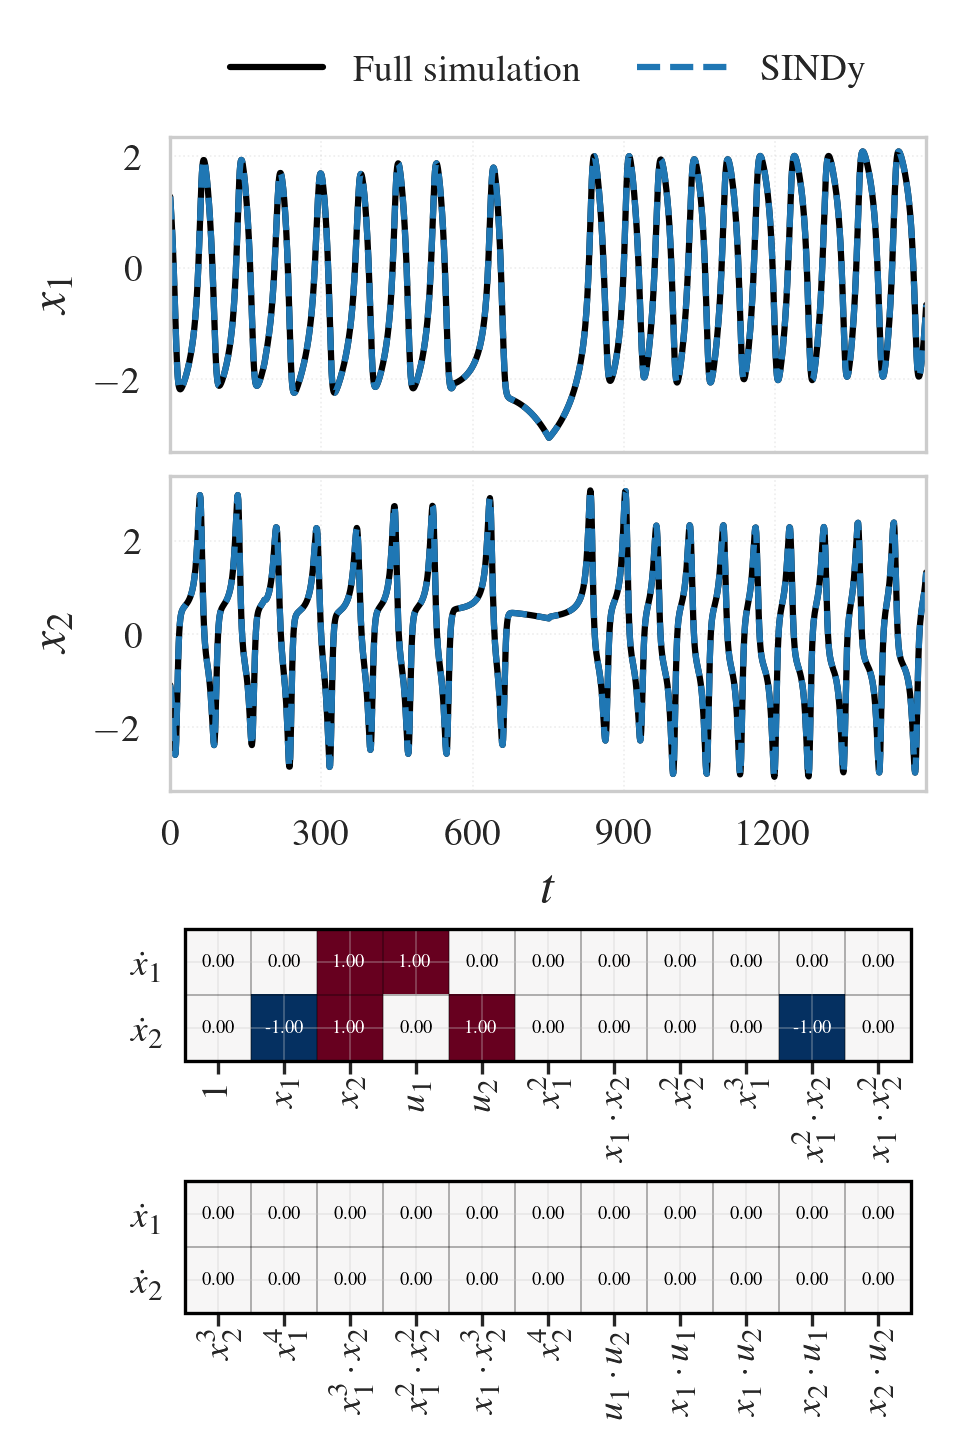

In [12]:
fig, axes_time, ax_h1, ax_h2 = plot_sindy_dynamics_automatica(
    test_output=test_output,
    test_data=test_data,
    sindy=sindy,
    nx=nx,
    convert_to_latex=convert_to_latex,
    output_path="VanDerPol_Dynamics.pdf",
    max_time_series_states=2,
    figure_mode="single",
    y_major_locator=2.0,
)

### Policy Evaluation

Compare the configured methods.


In [13]:
import torch
import torch.nn as nn
from neuromancer.dynamics.ode import ODESystem
import copy
class ODEVanDerPolControl(ODESystem):
    """
    Van der Pol oscillator with two inputs to achieve relative degree 1 for y = x1.

    Dynamics:
        x1' = x2 + u0
        x2' = mu * (1 - x1^2) * x2 - x1 + u1

    Inputs:
        u = [u0, u1] with shape (batch, 2)
        u0 acts directly on x1' (gives relative degree 1 for y = x1)
        u1 acts on x2'

    Shapes:
        insize=4 corresponds to [x1, x2, u0, u1]
        outsize=2 corresponds to [x1', x2']
    """
    def __init__(self, insize=4, outsize=2):
        super().__init__(insize=insize, outsize=outsize)
        self.mu = nn.Parameter(torch.tensor([1.0]), requires_grad=True)

    def ode_equations(self, x, u):
        x1 = x[:, [0]]
        x2 = x[:, [1]]
        u0 = u[:, [0]]
        u1 = u[:, [1]]
        dx1 = x2 + u0
        dx2 = self.mu * (1 - x1**2) * x2 - x1 + u1
        return torch.cat([dx1, dx2], dim=-1)


In [14]:
van_der_pol = ODEVanDerPolControl()                   # ODE system equations implemented in PyTorch
# Add parametric noise
van_der_pol.mu = torch.nn.Parameter(torch.tensor(gt_model.mu), requires_grad=False)
# integrate continuous time ODE# integrate continuous time ODE
gt_integrator = integrators.Euler(van_der_pol, h=torch.tensor(ts))   # using 4th order runge kutta integrator
# symbolic system model
gt_integrator_node = Node(gt_integrator, ['xn', 'u'], ['xn'], name='model')

SD_SINDy_policy_node = Node(
                lambda xn, r: torch.clamp(policy_sparse(xn, r), umin, umax),
                ['xn', 'r'], ['u'],
                name="policy_combined"
            )


SD_System= copy.deepcopy(System([SD_SINDy_policy_node,
                       gt_integrator_node]))

NN_System= copy.deepcopy(System([nn_policy,
                       gt_integrator_node]))


systems = {
    "SD-DPC": SD_System,
    "NN-DPC":    NN_System,
    # add more if you want them on the plot
}
# Example style map (same color per controller; your function uses it)
style_map = {
    "NN-DPC": ("-", 1.1, 0.5, "darkorange"),
    "MPC": ("-", 1.1, 0.5, "darkgreen"),
    "SD-DPC": ("-", 1.1, 0.94, "royalblue"),
}

In [15]:
import importlib
import utils

importlib.reload(utils)
from utils import *

In [16]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import patches
from matplotlib.lines import Line2D
from matplotlib.ticker import MaxNLocator, MultipleLocator
from pathlib import Path
from typing import Callable, Optional, Sequence, Union


def _to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.asarray(x)


def _apply_automatica_style():
    """
    Publication-style settings inspired by IFAC Automatica conventions.
    """
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
        "font.size": 9,
        "axes.labelsize": 12,
        "axes.titlesize": 10,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 9,
        "axes.linewidth": 0.8,
        "lines.linewidth": 1.0,
        "grid.linewidth": 0.4,
        "grid.alpha": 0.35,
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,
        "xtick.major.size": 3.0,
        "ytick.major.size": 3.0,
        "xtick.minor.size": 2.0,
        "ytick.minor.size": 2.0,
        "savefig.bbox": "tight",
        "figure.dpi": 300,
    })


def _draw_policy_heatmap(
    ax,
    data,
    xlabels,
    ylabels,
    cmap="RdBu_r",
    vmin=None,
    vmax=None,
    annot=True,
    annot_fmt=".2f",
    annot_fontsize=4.5,
    xrotation=90,
    border_linewidth=0.8,
):
    """
    Draw compact coefficient heatmap using matplotlib.
    data shape must be (n_outputs, n_terms).
    """
    n_rows, n_cols = data.shape

    if vmin is None or vmax is None:
        lim = np.nanmax(np.abs(data))
        if lim == 0 or not np.isfinite(lim):
            lim = 1.0
        vmin = -lim
        vmax = lim

    im = ax.imshow(
        data,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        aspect="equal",
        interpolation="none",
        origin="upper",
    )

    ax.set_xticks(np.arange(n_cols))
    ax.set_yticks(np.arange(n_rows))

    ax.set_xticklabels(xlabels)
    ax.set_yticklabels(ylabels)

    ax.tick_params(axis="x", rotation=xrotation, pad=1)
    ax.tick_params(axis="y", rotation=0, pad=4)
    ax.xaxis.tick_bottom()

    ax.set_xticks(np.arange(-0.5, n_cols, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, n_rows, 1), minor=True)

    ax.grid(
        which="minor",
        color="black",
        linestyle="-",
        linewidth=0.4,
    )

    ax.tick_params(which="minor", bottom=False, left=False)

    for spine in ax.spines.values():
        spine.set_visible(False)

    rect = patches.Rectangle(
        (-0.5, -0.5),
        n_cols,
        n_rows,
        linewidth=border_linewidth,
        edgecolor="black",
        facecolor="none",
        clip_on=False,
        zorder=10,
    )
    ax.add_patch(rect)

    if annot:
        lim = max(abs(vmin), abs(vmax))

        for i in range(n_rows):
            for j in range(n_cols):
                value = data[i, j]

                if abs(value) > 0.55 * lim:
                    text_color = "white"
                else:
                    text_color = "black"

                ax.text(
                    j,
                    i,
                    format(value, annot_fmt),
                    ha="center",
                    va="center",
                    fontsize=annot_fontsize,
                    color=text_color,
                )

    return im


def combined_controller_sparse_policy_automatica(
    Y_list,
    U_list,
    controller_labels,
    sparse_policy=None,
    convert_to_latex_policy: Optional[Callable] = None,
    fx_policy_labels=(r"$u_1$", r"$u_2$"),
    R=None,
    style_map=None,
    output_path: Union[str, Path] = "Combined_Controller_SparsePolicy.pdf",
    figure_mode: str = "double",
    fig_width_single: float = 4.0,
    fig_width_double: float = 7.0,
    state_panel_height_in: float = 1.05,
    control_panel_height_in: float = 1.05,
    heatmap_cell_width_in: float = 0.36,
    heatmap_cell_height_in: float = 0.30,
    heatmap_title_height_in: float = 0.18,
    heatmap_group_gap_in: float = 0.28,
    legend_height_in: float = 0.28,
    top_margin_in: float = 0.18,
    bottom_margin_in: float = 0.18,
    side_margin_in: float = 0.35,
    gap_after_legend_in: float = 0.08,
    gap_between_panels_in: float = 0.15,
    gap_before_heatmap_in: float = 0.42,
    heatmap_max_width_ratio: float = 0.88,
    state_axis_label: str = r"$x$",
    control_axis_label: str = r"$u$",
    time_label: str = r"$t$",
    state_indices: Sequence[int] = (0, 1),
    control_indices: Sequence[int] = (0, 1),
    state_linestyles=None,
    control_linestyles=None,
    reference_label: str = "Ref.",
    reference_color: str = "black",
    reference_linestyle: str = ":",
    reference_linewidth: float = 1.0,
    controller_linewidth: float = 1.4,
    xmin: Optional[float] = None,
    xmax: Optional[float] = None,
    umin: Optional[float] = None,
    umax: Optional[float] = None,
    y_major_locator: Optional[float] = 0.25,
    u_major_locator: Optional[float] = 0.25,
    heatmap_cmap: str = "RdBu_r",
    heatmap_vlim: Optional[float] = 5.0,
    heatmap_annot_fmt: str = ".2f",
    show_heatmap: bool = True,
    title: Optional[str] = None,
    show: bool = True,
    save: bool = True,
):
    """
    Automatica-style combined figure.

    It can show:
      1. state trajectories
      2. control trajectories
      3. optional sparse-policy coefficient heatmaps

    The sparse-policy heatmap is split into two stacked groups:
      1. Polynomial/product terms
      2. Trigonometric terms

    No heatmap colorbar is used.
    """

    _apply_automatica_style()

    if len(Y_list) != len(U_list):
        raise ValueError("Y_list and U_list must have the same length")

    if len(Y_list) != len(controller_labels):
        raise ValueError("controller_labels must match the number of trajectories")

    if len(Y_list) == 0:
        raise ValueError("Y_list and U_list cannot be empty")

    Y_list = [_to_numpy(Y) for Y in Y_list]
    U_list = [_to_numpy(U) for U in U_list]

    nsteps = Y_list[0].shape[0] - 1
    t_state = np.arange(nsteps + 1)
    t_control = np.arange(nsteps)

    for Y in Y_list:
        if Y.shape[0] != nsteps + 1:
            raise ValueError("All Y arrays must have the same time length")

    for U in U_list:
        if U.shape[0] != nsteps:
            raise ValueError("Each U array must have one fewer time step than Y")

    if R is not None:
        R = _to_numpy(R)

        if R.shape[0] < nsteps + 1:
            raise ValueError("R must have at least nsteps + 1 rows")

    if state_linestyles is None:
        state_linestyles = ["-"]

    if control_linestyles is None:
        control_linestyles = ["-"]

    if figure_mode == "single":
        fig_width = fig_width_single
    elif figure_mode == "double":
        fig_width = fig_width_double
    else:
        raise ValueError("figure_mode must be either 'single' or 'double'")

    coef_matrix = None
    function_names_latex = None
    ytick = None

    poly_indices = []
    trig_indices = []

    poly_width_in = 0.0
    trig_width_in = 0.0
    group_heatmap_height_in = 0.0
    total_heatmap_height_in = 0.0

    if show_heatmap:
        if sparse_policy is None:
            raise ValueError("sparse_policy must be provided when show_heatmap=True")

        if convert_to_latex_policy is None:
            raise ValueError("convert_to_latex_policy must be provided when show_heatmap=True")

        def clean_raw_function_name(name):
            name = str(name)

            # Remove coefficient 1 only inside trig terms
            # sin(1·x0) -> sin(x0)
            # cos(1·x1) -> cos(x1)
            # tan(1·r0) -> tan(r0)
            name = re.sub(
                r"(sin|cos|tan)\(\s*1\s*[·*]?\s*([xr]\d*)\s*\)",
                r"\1(\2)",
                name,
            )

            return name


        raw_function_names = list(getattr(sparse_policy.library, "function_names", []))

        raw_function_names = [
            clean_raw_function_name(name) for name in raw_function_names
        ]

        function_names_latex = convert_to_latex_policy(raw_function_names)

        n_terms = len(function_names_latex)

        coef = _to_numpy(sparse_policy.coef)

        if coef.ndim != 2:
            raise ValueError("sparse_policy.coef must be a 2D array")

        if coef.shape[0] == n_terms:
            coef_matrix = coef.T
        elif coef.shape[1] == n_terms:
            coef_matrix = coef
        else:
            raise ValueError(
                f"Unexpected coefficient shape {coef.shape} for {n_terms} terms"
            )

        n_outputs = coef_matrix.shape[0]

        if len(fx_policy_labels) < n_outputs:
            raise ValueError("fx_policy_labels must contain one label per policy output")

        ytick = list(fx_policy_labels)[:n_outputs]

        def is_trigonometric(raw_name, latex_name):
            raw_name = str(raw_name).lower()
            latex_name = str(latex_name).lower()

            trig_tokens = [
                "sin",
                "cos",
                "tan",
                r"\sin",
                r"\cos",
                r"\tan",
            ]

            return any(token in raw_name or token in latex_name for token in trig_tokens)

        for j, (raw_name, latex_name) in enumerate(zip(raw_function_names, function_names_latex)):
            if is_trigonometric(raw_name, latex_name):
                trig_indices.append(j)
            else:
                poly_indices.append(j)

        if len(poly_indices) == 0 and len(trig_indices) == 0:
            raise ValueError("No function terms found for the heatmap")

        max_heatmap_width_in = heatmap_max_width_ratio * fig_width

        if len(poly_indices) > 0:
            poly_width_in = min(
                len(poly_indices) * heatmap_cell_width_in,
                max_heatmap_width_in,
            )

        if len(trig_indices) > 0:
            trig_width_in = min(
                len(trig_indices) * heatmap_cell_width_in,
                max_heatmap_width_in,
            )

        group_heatmap_height_in = max(
            coef_matrix.shape[0] * heatmap_cell_height_in,
            0.55,
        )

        n_groups = int(len(poly_indices) > 0) + int(len(trig_indices) > 0)

        total_heatmap_height_in = (
            n_groups * group_heatmap_height_in
            + n_groups * heatmap_title_height_in
            + max(n_groups - 1, 0) * heatmap_group_gap_in
        )

    if show_heatmap:
        fig_height = (
            top_margin_in
            + legend_height_in
            + gap_after_legend_in
            + state_panel_height_in
            + gap_between_panels_in
            + control_panel_height_in
            + gap_before_heatmap_in
            + total_heatmap_height_in
            + bottom_margin_in
        )
    else:
        fig_height = (
            top_margin_in
            + legend_height_in
            + gap_after_legend_in
            + state_panel_height_in
            + gap_between_panels_in
            + control_panel_height_in
            + bottom_margin_in
        )

    fig = plt.figure(figsize=(fig_width, fig_height))

    def xnorm(x_in):
        return x_in / fig_width

    def ynorm(y_in):
        return y_in / fig_height

    content_width_in = fig_width - 2.0 * side_margin_in
    left_ts_in = side_margin_in
    width_ts_in = content_width_in

    current_top_in = fig_height - top_margin_in

    legend_bottom_in = current_top_in - legend_height_in

    legend_ax = fig.add_axes([
        xnorm(left_ts_in),
        ynorm(legend_bottom_in),
        xnorm(width_ts_in),
        ynorm(legend_height_in),
    ])

    legend_ax.axis("off")

    current_top_in = legend_bottom_in - gap_after_legend_in

    state_bottom_in = current_top_in - state_panel_height_in

    ax_x = fig.add_axes([
        xnorm(left_ts_in),
        ynorm(state_bottom_in),
        xnorm(width_ts_in),
        ynorm(state_panel_height_in),
    ])

    current_top_in = state_bottom_in - gap_between_panels_in
    control_bottom_in = current_top_in - control_panel_height_in

    ax_u = fig.add_axes([
        xnorm(left_ts_in),
        ynorm(control_bottom_in),
        xnorm(width_ts_in),
        ynorm(control_panel_height_in),
    ], sharex=ax_x)

    handles = []

    if style_map is None:
        colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

        style_map = {}

        for i, lbl in enumerate(controller_labels):
            style_map[lbl] = (
                "-",
                controller_linewidth,
                1.0,
                colors[i % len(colors)],
            )

    if R is not None:
        h_ref, = ax_x.plot(
            t_state,
            R[:nsteps + 1, state_indices[0]],
            linestyle=reference_linestyle,
            linewidth=reference_linewidth,
            color=reference_color,
            label=reference_label,
        )

        handles.append(h_ref)

    for i, lbl in enumerate(controller_labels):
        ls, lw, alpha, color = style_map[lbl]

        for k, state_id in enumerate(state_indices):
            ax_x.plot(
                t_state,
                Y_list[i][:, state_id],
                linestyle=ls,
                linewidth=lw,
                alpha=alpha,
                color=color,
            )

        for k, control_id in enumerate(control_indices):
            ax_u.plot(
                t_control,
                U_list[i][:, control_id],
                linestyle=ls,
                linewidth=lw,
                alpha=alpha,
                color=color,
            )

        handles.append(
            Line2D(
                [0],
                [0],
                color=color,
                label=lbl,
                linewidth=lw,
                linestyle=ls,
                alpha=alpha,
            )
        )

    legend_ax.legend(
        handles,
        [h.get_label() for h in handles],
        loc="center",
        ncol=len(handles),
        frameon=False,
        handlelength=2.5,
        columnspacing=1.4,
    )

    if xmin is None:
        xmin = 0

    if xmax is None:
        xmax = nsteps

    ax_x.set_xlim(xmin, xmax)

    if umin is not None:
        ax_u.axhline(
            umin,
            color="black",
            linewidth=0.8,
            linestyle=":",
        )

    if umax is not None:
        ax_u.axhline(
            umax,
            color="black",
            linewidth=0.8,
            linestyle=":",
        )

    ax_x.set_ylabel(state_axis_label, rotation=0, labelpad=12)
    ax_u.set_ylabel(control_axis_label, rotation=0, labelpad=12)

    ax_x.set_xlabel("")
    ax_u.set_xlabel(time_label)

    ax_x.tick_params(
        axis="x",
        which="both",
        bottom=False,
        labelbottom=False,
    )

    ax_x.grid(True, linestyle=":")
    ax_u.grid(True, linestyle=":")

    ax_x.xaxis.set_major_locator(MaxNLocator(nbins=5))
    ax_u.xaxis.set_major_locator(MaxNLocator(nbins=5))

    if y_major_locator is not None:
        ax_x.yaxis.set_major_locator(MultipleLocator(y_major_locator))

    if u_major_locator is not None:
        ax_u.yaxis.set_major_locator(MultipleLocator(u_major_locator))

    ax_h_poly = None
    ax_h_trig = None

    if show_heatmap:
        if heatmap_vlim is None:
            vmin = None
            vmax = None
        else:
            vmin = -abs(heatmap_vlim)
            vmax = abs(heatmap_vlim)

        def draw_group_heatmap(ax, data, xlabels, ylabels, group_title):
            im = ax.imshow(
                data,
                aspect="auto",
                cmap=heatmap_cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
            )

            ax.set_title(group_title, fontsize=8, pad=4)

            # Major ticks at cell centers for labels
            ax.set_xticks(np.arange(len(xlabels)))
            ax.set_xticklabels(
                xlabels,
                rotation=90,
                ha="center",
                va="top",
            )

            ax.set_yticks(np.arange(len(ylabels)))
            ax.set_yticklabels(ylabels)

            ax.tick_params(axis="x", length=0, pad=2)
            ax.tick_params(axis="y", length=0, pad=6)

            # Turn OFF major grid lines completely
            ax.grid(False)

            # Minor ticks at cell boundaries
            ax.set_xticks(np.arange(-0.5, len(xlabels), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(ylabels), 1), minor=True)

            # Draw borders only between cells
            ax.grid(
                which="minor",
                color="black",
                linestyle="-",
                linewidth=0.6,
            )

            ax.tick_params(which="minor", bottom=False, left=False)

            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(0.8)
                spine.set_color("black")

            for row in range(data.shape[0]):
                for col in range(data.shape[1]):
                    ax.text(
                        col,
                        row,
                        format(data[row, col], heatmap_annot_fmt),
                        ha="center",
                        va="center",
                        fontsize=7,
                        color="black",
                    )

            return im

        heatmap_top_in = control_bottom_in - gap_before_heatmap_in

        current_heatmap_top_in = heatmap_top_in

        if len(poly_indices) > 0:
            poly_data = coef_matrix[:, poly_indices]
            poly_labels = [function_names_latex[j] for j in poly_indices]

            poly_left_in = 0.5 * (fig_width - poly_width_in)

            poly_title_bottom_in = current_heatmap_top_in - heatmap_title_height_in
            poly_bottom_in = poly_title_bottom_in - group_heatmap_height_in

            ax_h_poly = fig.add_axes([
                xnorm(poly_left_in),
                ynorm(poly_bottom_in),
                xnorm(poly_width_in),
                ynorm(group_heatmap_height_in),
            ])

            draw_group_heatmap(
                ax=ax_h_poly,
                data=poly_data,
                xlabels=poly_labels,
                ylabels=ytick,
                group_title="Polynomial and product terms",
            )

            current_heatmap_top_in = poly_bottom_in - heatmap_group_gap_in

        if len(trig_indices) > 0:
            trig_data = coef_matrix[:, trig_indices]
            trig_labels = [function_names_latex[j] for j in trig_indices]

            trig_left_in = 0.5 * (fig_width - trig_width_in)

            trig_title_bottom_in = current_heatmap_top_in - heatmap_title_height_in
            trig_bottom_in = trig_title_bottom_in - group_heatmap_height_in

            ax_h_trig = fig.add_axes([
                xnorm(trig_left_in),
                ynorm(trig_bottom_in),
                xnorm(trig_width_in),
                ynorm(group_heatmap_height_in),
            ])

            draw_group_heatmap(
                ax=ax_h_trig,
                data=trig_data,
                xlabels=trig_labels,
                ylabels=ytick,
                group_title="Trigonometric terms",
            )

    if title is not None:
        fig.suptitle(title, fontsize=10, y=0.995)

    output_path = Path(output_path)

    if save:
        output_path.parent.mkdir(parents=True, exist_ok=True)
        fig.savefig(output_path, transparent=False)
        print(f"Saved {output_path}")

    if show:
        plt.show()

    return fig, ax_x, ax_u, ax_h_poly, ax_h_trig

In [31]:
systems = {
    "SD-DPC": SD_System,
    "NN-DPC":    NN_System,
    # add more if you want them on the plot
}

nseeds=1
nsteps = 50
Y_list, U_list, controller_labels, R, losses = run_multi_seed_rollouts(
    systems=systems,
    nsteps=nsteps,
    nx=nx, nu=nu, nref=nref,
    xmin=xmin, xmax=xmax, umin=umin, umax=umax,
    device=device,
    n_seeds=nseeds,
    seed0=21,
    include_mpc=True,
    mpc_fn=vdp_mpc_solve,
    mpc_kwargs=dict(vdp_system=gt_model, N=50, nsim=nsteps, Rdu=0.02)
)




Saved VanDerPol_Control_Traj_Coefs.pdf


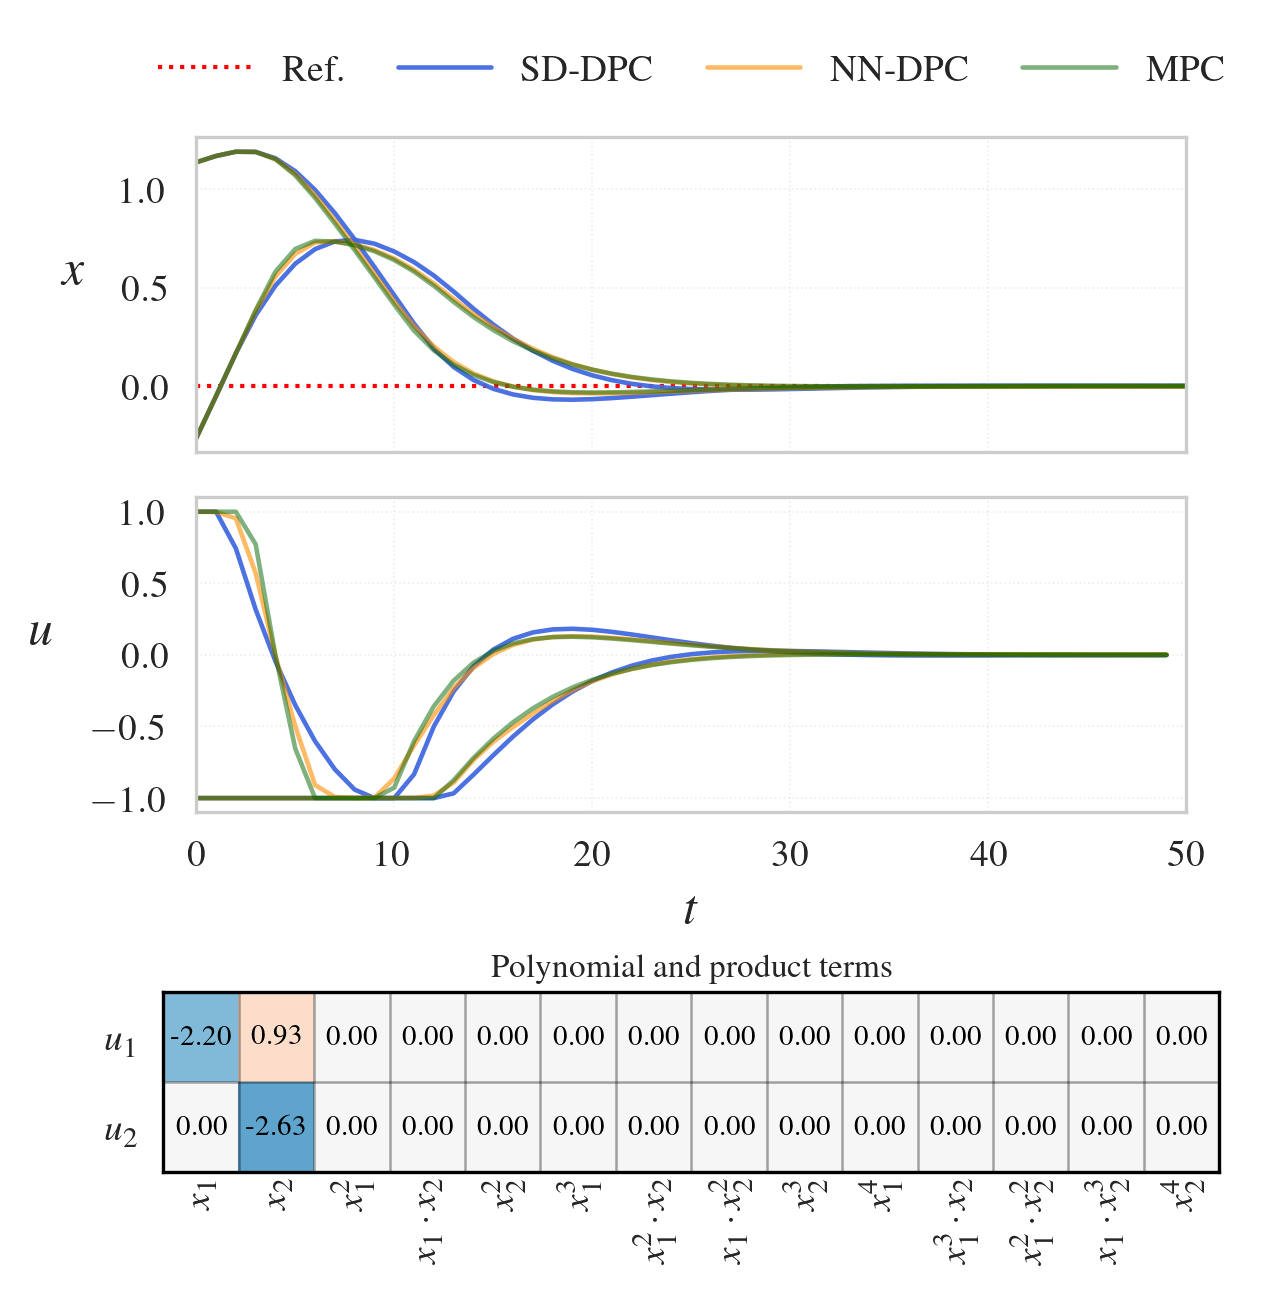

In [32]:
# Example style map (same color per controller; your function uses it)
style_map = {
    "NN-DPC": ("-", 1.1, 0.6, "darkorange"),
    "MPC": ("-", 1.1, 0.5, "darkgreen"),
    "SD-DPC": ("-", 1.1, 0.94, "royalblue"),
}

fig, ax_x, ax_u, ax_h_poly, ax_h_trig = combined_controller_sparse_policy_automatica(
    Y_list=Y_list,
    U_list=U_list,
    controller_labels=controller_labels,
    sparse_policy=policy_sparse,
    convert_to_latex_policy=convert_to_latex_policy,
    R=R,
    reference_label= "Ref.",
    reference_color= "red",
    reference_linestyle = ":",
    style_map=style_map,
    output_path="VanDerPol_Control_Traj_Coefs.pdf",
    figure_mode="single",
    show_heatmap=True,
    y_major_locator=0.5,
    u_major_locator=0.5,
)


In [38]:
systems = {
    "SD-DPC": SD_System,
    "NN-DPC":    NN_System,
    "MPC_adapt": None,  # the value is ignored; name prefix "MPC" triggers mpc_solver
}

summary = evaluate_controllers_over_seeds(
    systems_dict=systems,
    nsteps=50,
    nx=nx,
    xmin=xmin,
    xmax=xmax,
    n_seeds=1000,
    torch_device = device,
    # MPC bits (optional; only used for names starting with "MPC")
    mpc_solver=vdp_mpc_solve,
    mpc_model=gt_model,
    mpc_params=dict(
        N=50, Rdu=0.0)
)


=== Evaluating controller: SD-DPC ===
  Seed 1/1000...
  Seed 20/1000...
  Seed 40/1000...
  Seed 60/1000...
  Seed 80/1000...
  Seed 100/1000...
  Seed 120/1000...
  Seed 140/1000...
  Seed 160/1000...
  Seed 180/1000...
  Seed 200/1000...
  Seed 220/1000...
  Seed 240/1000...
  Seed 260/1000...
  Seed 280/1000...
  Seed 300/1000...
  Seed 320/1000...
  Seed 340/1000...
  Seed 360/1000...
  Seed 380/1000...
  Seed 400/1000...
  Seed 420/1000...
  Seed 440/1000...
  Seed 460/1000...
  Seed 480/1000...
  Seed 500/1000...
  Seed 520/1000...
  Seed 540/1000...
  Seed 560/1000...
  Seed 580/1000...
  Seed 600/1000...
  Seed 620/1000...
  Seed 640/1000...
  Seed 660/1000...
  Seed 680/1000...
  Seed 700/1000...
  Seed 720/1000...
  Seed 740/1000...
  Seed 760/1000...
  Seed 780/1000...
  Seed 800/1000...
  Seed 820/1000...
  Seed 840/1000...
  Seed 860/1000...
  Seed 880/1000...
  Seed 900/1000...
  Seed 920/1000...
  Seed 940/1000...
  Seed 960/1000...
  Seed 980/1000...
  Seed 1000/1000.

In [39]:
summary

,tracking_mse_mean,tracking_mse_std,tracking_mse_max,tracking_mse_min,violation_mse_mean,violation_mse_std,violation_mse_max,violation_mse_min,time_mean,time_std,time_max,time_min
controller,,,,,,,,,,,,
SD-DPC,0.028568,0.020295,0.087887,0.000138,0.0,0.0,0.0,0.0,0.005626,0.001540,0.023234,0.004908
NN-DPC,0.027805,0.020033,0.088785,0.000131,0.0,0.0,0.0,0.0,0.006323,0.000914,0.014504,0.005716
MPC_adapt,0.027458,0.019824,0.088401,0.000134,0.0,0.0,0.0,0.0,0.635257,0.080755,2.092387,0.565336


In [45]:
import torch
import time

def benchmark_policy(policy, nx=2, nref=1, batch_size=1024, iters=2000, device="cpu"):
    # Random test inputs
    X = torch.rand(batch_size, nx, device=device)
    R = torch.rand(batch_size, nref, device=device)

    policy.eval()
    with torch.no_grad():
        # Warm-up (especially important for GPU timing)
        for _ in range(10):
            _ = policy(X, R)

        if device == "cuda":
            torch.cuda.synchronize()

        start = time.time()
        for _ in range(iters):
            _ = policy(X, R)
        if device == "cuda":
            torch.cuda.synchronize()

    total_time = (time.time() - start)
    avg_time = total_time / iters
    return avg_time*1e6



In [55]:
avgs_SD = []
avgs_NN = []
for _ in range(500):
    avg_SD = benchmark_policy(policy_sparse, nx=2, nref=2, batch_size=1, iters=1000, device="cpu")
    avg_NN = benchmark_policy(net_policy, nx=2, nref=2, batch_size=1, iters=1000, device="cpu")
    avgs_SD.append(avg_SD)
    avgs_NN.append(avg_NN)


In [56]:
print(np.mean(avgs_SD))
print(np.mean(avgs_NN))

26.264721393585205
42.51755428314209
